In [2]:
import sklearn.cluster
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy import optimize
import sklearn
# import geom3d
import igl
import meshplot as mp

[-8.20902053e-04  2.57345354e-03  9.99996352e-01]


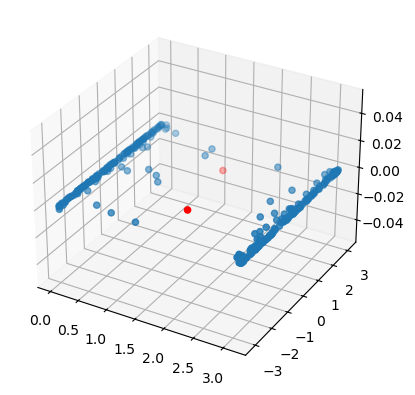

[[ 1.72745071 -1.26642911]
 [ 1.59648951  1.32388303]]
[ 0.29601977 -0.94235439 -0.15601444]
[ 0.24433137  0.96935143 -0.02569036]


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [7]:
class Cylinder:
    def __init__(self, v, f):
        self.v = v
        self.f = f
        
        self.f_center = np.mean(v[f], axis=1)
        self.f_area = igl.doublearea(v, f) / 2
        self.f_normal = igl.per_face_normals(v, f, np.array([1., 0., 0.]))
        self.f_normal = self.f_normal / np.linalg.norm(self.f_normal, axis=1).reshape(-1, 1)
        
    def fit(self):
        points = self.v[list(set(self.f.flatten()))]
        
        # get axis by pca
        centroid = np.mean(points, axis=0)
        points_centered = points - centroid
        covariance = np.cov(points_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        axis_normal = eigenvectors[:, np.argmax(eigenvalues)]
        axis_normal = np.array(axis_normal)
        axis_normal /= np.linalg.norm(axis_normal)
        print(axis_normal)
        
        # get axis by normal
        f_normal = self.f_normal
        sample_axis = []
        # sample 3 from points for 100 times
        for _ in range(300):
            index = np.random.choice(points.shape[0], 3, replace=False)
            cur_normal = f_normal[index]
            cur_axis = np.cross(cur_normal[1] - cur_normal[0], cur_normal[2] - cur_normal[0])
            cur_axis /= np.linalg.norm(cur_axis)
            sample_axis.append(cur_axis)
        sample_axis = np.array(sample_axis)
        sample_angles = np.zeros((sample_axis.shape[0], 2))
        sample_angles[:, 0] = np.arccos(sample_axis[:, 2])
        sample_angles[:, 1] = np.arctan2(sample_axis[:, 1], sample_axis[:, 0])
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(sample_angles[:, 0], sample_angles[:, 1])
        
        ms = sklearn.cluster.MeanShift(
            cluster_all=False
        )
        ms.fit(sample_angles)
        cluster_centers = ms.cluster_centers_
        ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='r')
        plt.show()
        print(cluster_centers)
        
        axis1 = np.array([
            np.sin(cluster_centers[0, 0]) * np.cos(cluster_centers[0, 1]),
            np.sin(cluster_centers[0, 0]) * np.sin(cluster_centers[0, 1]),
            np.cos(cluster_centers[0, 0])
        ])
        print(axis1)
        axis2 = np.array([
            np.sin(cluster_centers[1, 0]) * np.cos(cluster_centers[1, 1]),
            np.sin(cluster_centers[1, 0]) * np.sin(cluster_centers[1, 1]),
            np.cos(cluster_centers[1, 0]) 
        ])
        print(axis2)
        
        plot = mp.plot(self.v, self.f, shading={"wireframe": True})
        points_center = np.mean(points, axis=0)
        plot.add_lines(
            np.array([points_center]),
            np.array([points_center + axis_normal * 10]),
            shading={
                "line_color": "red",
                "line_width": 5
            }
        )
        plot.add_lines(
            np.array([points_center]),
            np.array([points_center + axis1 * 10]),
            shading={
                "line_color": "blue",
                "line_width": 5
            }
        )
        plot.add_lines(
            np.array([points_center]),
            np.array([points_center + axis2 * 10]),
            shading={
                "line_color": "green",
                "line_width": 5
            }
        )
v, f = igl.read_triangle_mesh('../cylinder3.obj')
cylinder_fit = Cylinder(v, f)
cylinder_fit.fit()